In [28]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [29]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


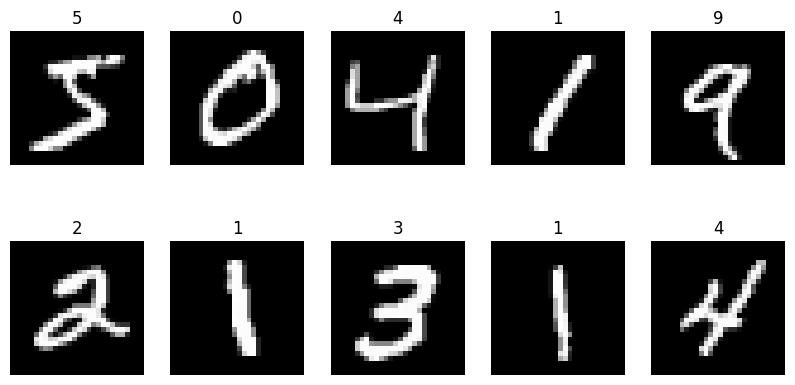

In [30]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [31]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [32]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [33]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Conclusion

This project developed a handwritten digit recognition system using the MNIST dataset and a neural network built with TensorFlow and Keras. The model achieved a test accuracy of 97.58%, demonstrating effective image classification performance.

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9224 - loss: 0.2656 - val_accuracy: 0.9582 - val_loss: 0.1383
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9665 - loss: 0.1129 - val_accuracy: 0.9669 - val_loss: 0.1122
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9758 - loss: 0.0789 - val_accuracy: 0.9687 - val_loss: 0.1044
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0.9706 - val_loss: 0.0961
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9854 - loss: 0.0462 - val_accuracy: 0.9719 - val_loss: 0.0999


In [23]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9747 - loss: 0.0924
Test Accuracy: 0.9746999740600586


In [24]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


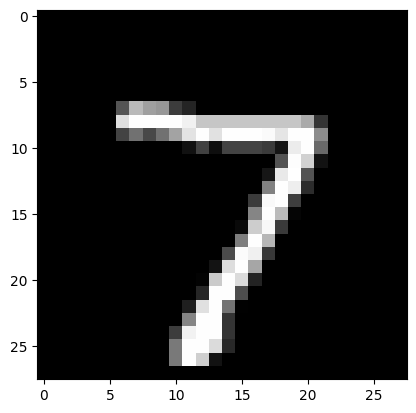

Predicted Digit: 7
Actual Digit: 7


In [25]:
plt.imshow(X_test[0], cmap='gray')
plt.show()

print("Predicted Digit:", np.argmax(predictions[0]))
print("Actual Digit:", y_test[0])

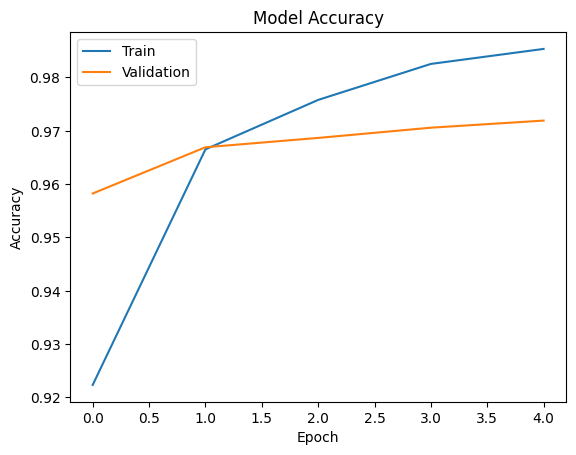

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [27]:
model.save("mnist_model.keras")